In [83]:
import librosa
import soundfile as sf
import os
import math
import numpy as np
import glob
import matplotlib.pyplot as plt

In [2]:
input_folder = r"/home/pom/code/Pom-Savitree/maestro-v3.0.0-mp3/maestro-v3.0.0-mp3/2018"
output_dir = r"/home/pom/code/Pom-Savitree/maestro-v3.0.0-mp3/Output"

In [130]:
class AudioPreprocessingPipeline:
    # NOTE: Should we add streaming input/output? Currently we only input files and output to directories.
    def __init__(self,
                 slice_duration: int = 20,
                 n_mels: int = 128,
                 n_fft: int = 2048,
                 hop_length: int = 512):
        self.slice_duration = slice_duration
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length



    def split_audio(
        self,
        file_path: str
        ) -> np.ndarray:
        '''
        Takes in a file_path.
        Returns a numpy array containing the mel spectrograms of the splitted audio.
        '''
        total_duration = librosa.get_duration(path=file_path)
        total_slices = math.floor(total_duration / self.slice_duration)

        # n * sr / hopl
        file_sr = librosa.get_samplerate(file_path)
        n_frames = (self.slice_duration * file_sr) // self.hop_length + 1
        all_mel_specs = np.zeros(shape=(self.n_mels, int(n_frames), total_slices))

        for i in range(total_slices):
            # The current slice should start here
            start_time = i * self.slice_duration
            remaining_time = total_duration - start_time
            current_duration = min(remaining_time, self.slice_duration)

            # Skipping slicing if less than 2 sec
            # if current_duration < 2:
                # continue

            # Get the audio time series (y) and the sampling rate (sr) of the current audio slice
            y, _ = librosa.load(file_path, sr=file_sr, offset=start_time, duration=current_duration)
            mel_spec = librosa.feature.melspectrogram(y=y, sr=file_sr, n_mels=self.n_mels, n_fft=self.n_fft, hop_length=self.hop_length)

            # Convert amplitude to log scale (decibels / dB)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

            all_mel_specs[:, :, i] = mel_spec_db

        return all_mel_specs


    def save_array(
        self,
        mel_spec_mat: np.ndarray,
        file_name: str,
        output_dir: str = os.getcwd() + '/preproc_output',
        ) -> None:
        '''
        Saving Mel-Spectrogram Matrix as a NumPy binary file (.npy) from one song.
        '''
        # Create a specific output directory
        if not os.path.exists(output_dir):
            os.makedirs(output_dir, exist_ok=True)

        file_basename = os.path.splitext(os.path.basename(file_name))[0]
        npy_path = os.path.join(self.output_dir, f"{file_basename}.npy")
        np.save(npy_path, mel_spec_mat)


    def save_mel_spec_images(
        self,
        mel_spec_mat: np.ndarray,
        file_name: str,
        output_dir: str = os.getcwd() + '/mel_spec_images',
        ) -> None:
        '''
        Save all Mel-Spectrogram images into a single output directory.
        '''
        # Create a specific output directory
        if not os.path.exists(output_dir):
            os.makedirs(output_dir, exist_ok=True)

        for idx in range(mel_spec_mat.shape[-1]):
            # Getting filename
            file_basename = os.path.splitext(os.path.basename(file_name))[0]
            base_filename = f"{file_basename}_Split_Part_{idx+1}"
            plt.imsave(output_dir + '/' + base_filename + '.png', mel_spec_mat[:, :, idx])


    def run_from_folder(
        self,
        input_folder: str,
        ):
        # numpy array for each of the files in the folder.
        '''
        Takes an input folder and loops over all songs in that folder.
        Creates a 3D numpy array containing all Mel-Spectrograms for each song.

        Yields a tuple of (file_path, mel_spec_array) for each .mp3 file in the folder.
        '''
        # Searching for mp3 files
        mp3_files = glob.glob(os.path.join(input_folder, "*.mp3"))

        for index, current_file in enumerate(mp3_files):
            print(f"[{index+1}/{len(mp3_files)}] Processing: {os.path.basename(current_file)}")
            yield current_file, self.split_audio(current_file)


In [131]:
pipeline = AudioPreprocessingPipeline(
    slice_duration=20,
    n_mels=128,
    hop_length=512
)

In [132]:
all_mel_specs = pipeline.split_audio('data/recital1-3.mp3')
all_mel_specs

array([[[-30.98641968, -18.85022736, -27.5036087 , ..., -35.52899933,
         -20.98556519, -15.37842464],
        [-25.86738205, -16.42490387, -25.5260582 , ..., -35.45708466,
         -18.29668808, -16.04863548],
        [-23.94438171, -15.36755848, -22.19368744, ..., -51.24242401,
         -22.45571709, -19.75613976],
        ...,
        [-18.18712044, -17.03633881, -24.3123436 , ..., -39.80606461,
         -30.86726761,  -7.52096844],
        [-16.30326843, -17.06114769, -22.93208694, ..., -42.28178406,
         -25.3470211 ,  -7.4989748 ],
        [-17.15608788, -23.20330048, -24.67053986, ..., -41.89959717,
         -24.40379143,  -8.81049442]],

       [[-36.02758026, -24.85195923, -33.25196838, ..., -37.74012375,
         -29.77296257, -19.70272636],
        [-37.65088272, -28.29354477, -34.85569   , ..., -38.57395935,
         -29.01119423, -22.8095665 ],
        [-31.77804184, -26.07023621, -32.03141403, ..., -47.75543213,
         -31.96409607, -21.53040314],
        ...,


In [133]:
pipeline.save_mel_spec_images(all_mel_specs, 'recital', './output_mel_img')

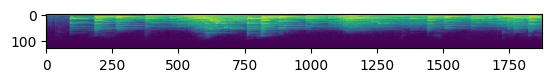

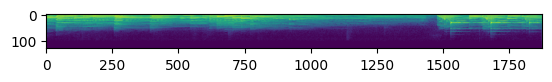

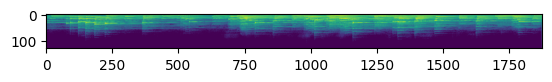

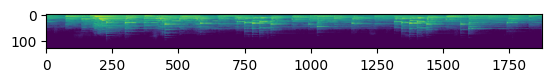

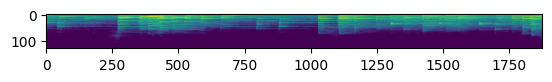

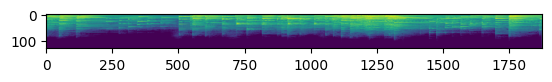

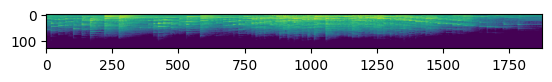

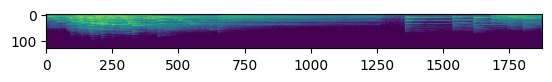

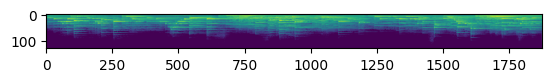

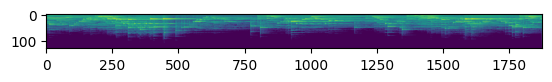

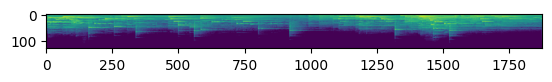

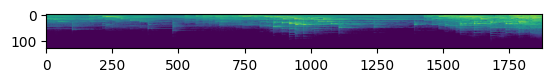

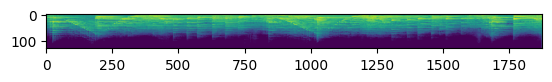

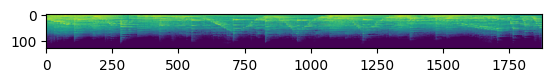

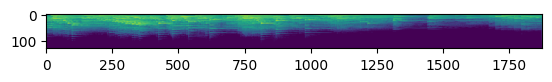

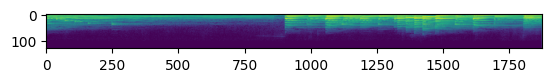

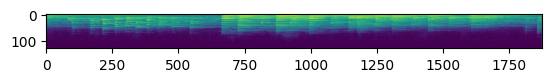

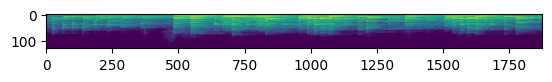

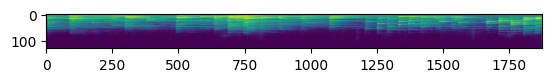

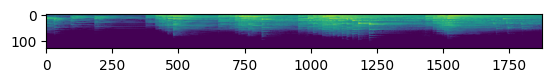

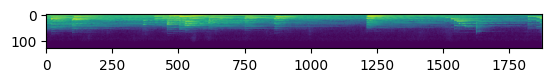

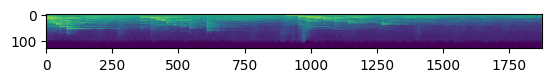

In [ ]:
for idx in range(all_mel_specs.shape[-1]):
    plt.imshow(all_mel_specs[:,:, idx])
    plt.show()


In [135]:
for file_path, mel_spec in pipeline.run_from_folder('data/mp3s'):
    print(file_path, mel_spec.shape)

[1/8] Processing: recital1-3 copy.mp3
data/mp3s/recital1-3 copy.mp3 (128, 1876, 22)
[2/8] Processing: recital1-3.mp3
data/mp3s/recital1-3.mp3 (128, 1876, 22)
[3/8] Processing: recital1-3 copy 2.mp3
data/mp3s/recital1-3 copy 2.mp3 (128, 1876, 22)
[4/8] Processing: recital1-3 copy 3.mp3
data/mp3s/recital1-3 copy 3.mp3 (128, 1876, 22)
[5/8] Processing: recital1-3 copy 7.mp3
data/mp3s/recital1-3 copy 7.mp3 (128, 1876, 22)
[6/8] Processing: recital1-3 copy 6.mp3
data/mp3s/recital1-3 copy 6.mp3 (128, 1876, 22)
[7/8] Processing: recital1-3 copy 4.mp3
data/mp3s/recital1-3 copy 4.mp3 (128, 1876, 22)
[8/8] Processing: recital1-3 copy 5.mp3
data/mp3s/recital1-3 copy 5.mp3 (128, 1876, 22)


In [34]:
1876 * 22 + 291

41563

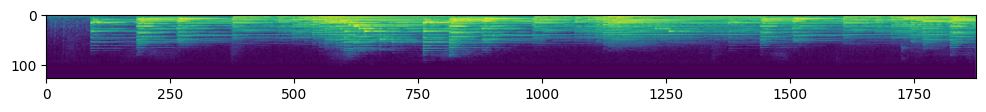

In [10]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 10))
plt.imshow(arr)

In [121]:
long_list = [x**2 for x in range(10_000_000)]

In [122]:
import sys
sys.getsizeof(long_list) / 1024 / 1024

84.96776580810547

In [ ]:
long_gen = (x**2 for x in range(10_000_000))

In [125]:
sys.getsizeof(long_gen)

104

In [124]:
type(long_list), type(long_gen)

(list, generator)

In [126]:
for x in long_gen:
    y = 2 * x

In [129]:
range(100000000000000000000000000000000000000000)

range(0, 100000000000000000000000000000000000000000)